**DTASET PROBLEM** : This project analyzes the Netflix dataset to understand trends in movies and TV shows available on the platform. The goal is to explore patterns such as content type distribution, release trends, and ratings to gain insights into Netflix's content strategy.

## Importing Libraries

Pandas and NumPy are used for data handling, while Matplotlib and Seaborn are used for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and Inspecting the Dataset

In this step, the dataset is loaded into a Pandas DataFrame using the `read_csv()` function. After loading, the dataset is inspected to understand its structure and contents.

- `df.head()` displays the first five rows of the dataset, helping to understand the type of data present.
- `df.shape` provides the number of rows and columns in the dataset.
- `df.dtypes` shows the data type of each column, which is important for identifying numerical and categorical features.

This step helps in gaining an initial understanding of the dataset before performing further analysis.

In [21]:
df = pd.read_csv("Netflix Shows.csv", encoding='latin1')

In [22]:
df.head()
df.shape
df.dtypes

,0
title,object
rating,object
ratingLevel,object
ratingDescription,int64
release year,int64
user rating score,float64
user rating size,int64


## Data Cleaning

Data cleaning is a crucial step in data analysis as real-world datasets often contain missing or duplicate values.

- Missing values are identified using `isnull().sum()`.
- These missing values are handled using forward fill (`fillna(method='ffill')`), which replaces missing entries with the previous valid value.
- Duplicate rows are checked using `duplicated()` and removed using `drop_duplicates()` to ensure that the dataset does not contain repeated information.

This step ensures that the dataset is clean, consistent, and ready for analysis.

In [23]:
df.isnull().sum()

,0
title,0
rating,0
ratingLevel,59
ratingDescription,0
release year,0
user rating score,395
user rating size,0


In [24]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [25]:
df.dropna(inplace=True)

In [26]:
df.drop_duplicates(inplace=True)

## Statistical Analysis

In this step, statistical measures are calculated for numerical columns such as 'release_year' and 'duration'.

The following measures are computed:
- **Mean:** Average value of the data
- **Median:** Middle value when data is sorted
- **Mode:** Most frequently occurring value
- **Standard Deviation:** Measure of data spread
- **Variance:** Square of standard deviation
- **Range:** Difference between maximum and minimum values
- **Mid-range:** Average of maximum and minimum values

These statistics help in understanding the central tendency and variability of the dataset.

In [29]:
col = 'release year'

print("Mean:", df[col].mean())
print("Median:", df[col].median())
print("Mode:", df[col].mode()[0])
print("Standard Deviation:", df[col].std())
print("Variance:", df[col].var())
print("Range:", df[col].max() - df[col].min())
print("Mid-range:", (df[col].max() + df[col].min()) / 2)

Mean: 2010.591006423983
Median: 2014.0
Mode: 2016
Standard Deviation: 7.960050766948967
Variance: 63.362408212404844
Range: 77
Mid-range: 1978.5


In [35]:
df['ratingLevel'] = df['ratingLevel'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2479/3831201561.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['ratingLevel'] = df['ratingLevel'].str.extract('(\d+)').astype(float)


In [36]:
df['release year'].mean()
df['release year'].median()
df['release year'].mode()
df['release year'].std()
df['release year'].var()

df['release year'].max() - df['release year'].min()
(df['release year'].max() + df['release year'].min()) / 2

1978.5

In [37]:
df['ratingDescription'].mean()
df['ratingDescription'].median()
df['ratingDescription'].mode()
df['ratingDescription'].std()
df['ratingDescription'].var()

df['ratingDescription'].max() - df['ratingDescription'].min()
(df['ratingDescription'].max() + df['ratingDescription'].min()) / 2

67.0

## Histogram of Release Year

A histogram is used to visualize the distribution of a numerical variable.

In this case, it shows how Netflix content is distributed across different release years. It helps identify trends such as whether most content is recent or older.

This visualization provides insights into Netflix's focus on content production over time.

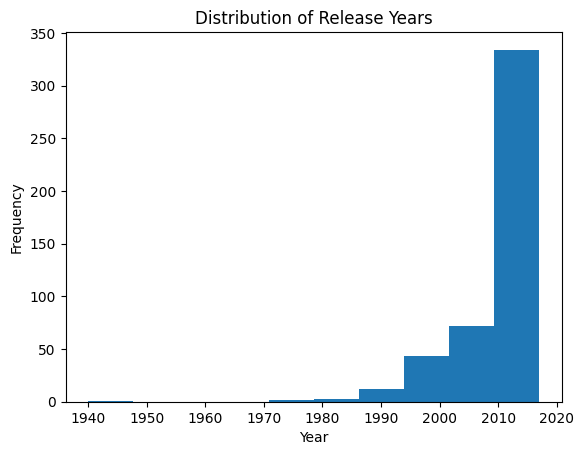

In [38]:
plt.hist(df['release year'])
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

## Countplot of Content Type

A countplot is used to display the number of occurrences of each category in a categorical variable.

Here, it shows the number of Movies and TV Shows available on Netflix. This helps in understanding the composition of content on the platform.

It provides a clear comparison between different content types.

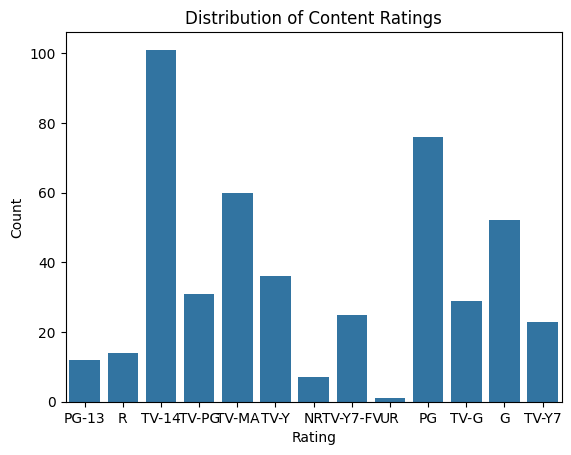

In [41]:
sns.countplot(x='rating', data=df)
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Boxplot of Duration

A boxplot is used to visualize the spread and distribution of numerical data and to detect outliers.

In this case, it shows how the duration of content varies. The box represents the interquartile range, while the whiskers indicate variability outside the upper and lower quartiles.

Outliers in the plot indicate content with unusually long or short durations.

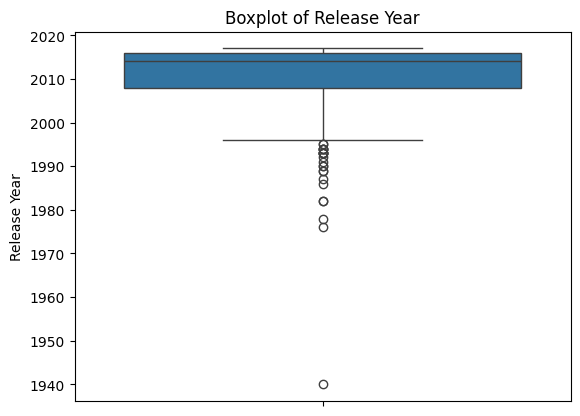

In [42]:
sns.boxplot(y=df['release year'])
plt.title("Boxplot of Release Year")
plt.ylabel("Release Year")
plt.show()

## Correlation Heatmap

A heatmap is used to visualize the correlation between numerical variables in the dataset.

Correlation values range from -1 to +1:
- Values close to +1 indicate strong positive correlation
- Values close to -1 indicate strong negative correlation
- Values near 0 indicate weak or no correlation

This helps identify relationships between variables such as release year and duration.

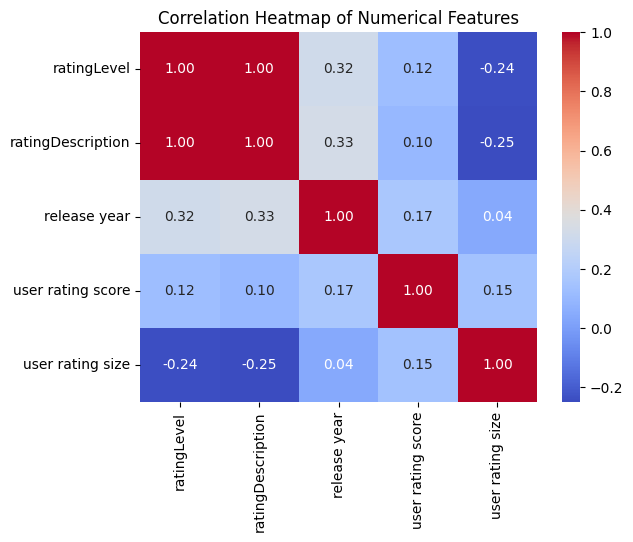

In [43]:
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Predictive Modeling

In this step, a machine learning model is built to predict whether a Netflix title is a Movie or a TV Show.

- Categorical variables are converted into numerical format using encoding.
- The dataset is split into training (80%) and testing (20%) sets.
- A Logistic Regression model is used for classification.

This model helps in understanding how different features influence the type of content.

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [47]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('rating_TV-14', axis=1)
y = df_encoded['rating_TV-14']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Impute missing values using the mean strategy
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_imputed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [51]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_imputed)
accuracy_score(y_test, y_pred)

1.0

## Insights

1. Most content on Netflix is movies rather than TV shows.
2. The majority of content is released after 2000, showing a focus on modern entertainment.
3. Duration varies widely, with some outliers indicating very long content.

## Recommendations

1. Netflix can continue investing in modern content as it dominates the platform.
2. Increasing high-quality TV shows may improve user engagement.